<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/jw/nzvjjpvn4xj6z93q0mpv35fh0000gn/T/ipykernel_2180/2094143726.py:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  titles =[f'线性核 SVM (C={C_value})', f'高斯核 SVM (C={C_value}, $\gamma$=10)']


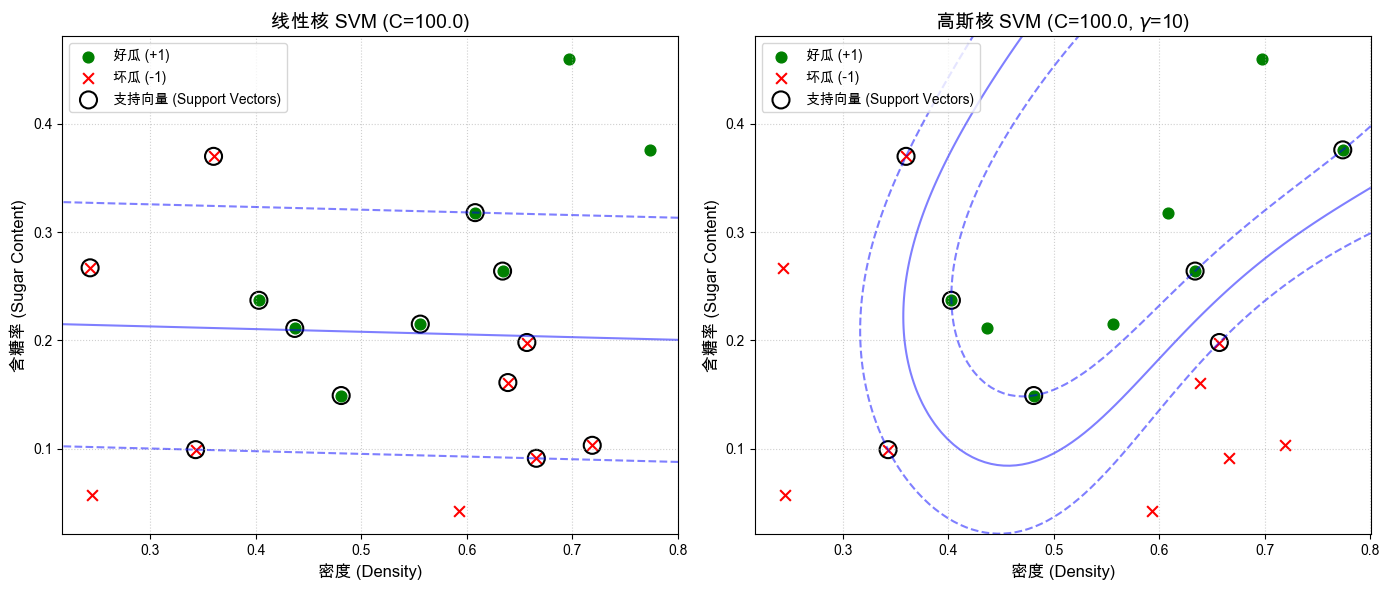

--- 实验结果 ---
线性核 SVM 的支持向量编号 (共 13 个): [ 9 10 12 13 14 15 17  3  4  5  6  7  8]
高斯核 SVM 的支持向量编号 (共 7 个): [12 14 15  2  3  6  7]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# 解决 Matplotlib 中文显示问题（Windows/Linux 常用 SimHei，Mac 可改为 'Arial Unicode MS'）
# Mac 常用中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者尝试：plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# 1. 准备西瓜数据集 3.0alpha
X = np.array([
    [0.697, 0.460],[0.774, 0.376], [0.634, 0.264],[0.608, 0.318],[0.556, 0.215], [0.403, 0.237],[0.481, 0.149], [0.437, 0.211], # 1-8 是好瓜
    [0.666, 0.091], [0.243, 0.267],[0.245, 0.057], [0.343, 0.099],[0.639, 0.161],[0.657, 0.198], [0.360, 0.370],[0.593, 0.042], [0.719, 0.103]  # 9-17 是坏瓜
])
y = np.array([1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

# 2. 训练模型 (保持 C=100, 高斯核 gamma=10 以凸显差异)
C_value = 100.0
svm_linear = svm.SVC(kernel='linear', C=C_value)
svm_rbf = svm.SVC(kernel='rbf', gamma=10, C=C_value)

svm_linear.fit(X, y)
svm_rbf.fit(X, y)

# 获取支持向量的索引 (注意：Python 索引从 0 开始，题目编号从 1 开始，需 +1)
sv_idx_linear = svm_linear.support_ + 1
sv_idx_rbf = svm_rbf.support_ + 1

# 3. 创建画板 (1行2列)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles =[f'线性核 SVM (C={C_value})', f'高斯核 SVM (C={C_value}, $\gamma$=10)']
models =[svm_linear, svm_rbf]

for ax, model, title in zip(axes, models, titles):
    # 3.1 绘制原始数据点
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='green', marker='o', s=60, label='好瓜 (+1)')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='red', marker='x', s=60, label='坏瓜 (-1)')

    # 3.2 圈出支持向量
    # edgecolors='k' 黑色边框，facecolors='none' 内部透明
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
               s=150, facecolors='none', edgecolors='k', linewidths=1.5, 
               label='支持向量 (Support Vectors)')

    # 3.3 绘制决策边界和间隔边界
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格点以评估模型
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # 获取网格上每个点的决策函数值
    Z = model.decision_function(xy).reshape(XX.shape)

    # 绘制等高线：
    # Z=0 是决策边界 (实线)
    # Z=-1, Z=1 是间隔边界 (虚线)
    ax.contour(XX, YY, Z, colors='blue', levels=[-1, 0, 1], alpha=0.5, 
               linestyles=['--', '-', '--'])

    # 3.4 图形设置
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('密度 (Density)', fontsize=12)
    ax.set_ylabel('含糖率 (Sugar Content)', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
print("--- 实验结果 ---")
print(f"线性核 SVM 的支持向量编号 (共 {len(sv_idx_linear)} 个): {sv_idx_linear}")
print(f"高斯核 SVM 的支持向量编号 (共 {len(sv_idx_rbf)} 个): {sv_idx_rbf}")